In [10]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
from scipy.stats import skew



---
## 2. Load data

In [11]:
df = pd.read_csv('./clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [12]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [13]:
price_df = pd.read_csv(r'E:\DS\tezendra\Projects\Job Simulation of BCG X\Task 1\price_data (1).csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [14]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [15]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

price_df['total_off_peak'] = price_df['price_off_peak_var'] + price_df['price_off_peak_fix']
price_df['total_peak']     = price_df['price_peak_var'] + price_df['price_peak_fix']
price_df['total_mid_peak'] = price_df['price_mid_peak_var'] + price_df['price_mid_peak_fix']

monthly = price_df.groupby(['id', 'price_date']).agg({
    'total_off_peak': 'mean',
    'total_peak': 'mean',
    'total_mid_peak': 'mean',
    'price_off_peak_var': 'mean',
    'price_peak_var': 'mean',
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'
}).reset_index()

monthly['peak_off_diff'] = monthly['total_peak'] - monthly['total_off_peak']
monthly['mid_off_diff']  = monthly['total_mid_peak'] - monthly['total_off_peak']
monthly['peak_mid_diff'] = monthly['total_peak'] - monthly['total_mid_peak']

avg_diff = monthly.groupby('id')[['peak_off_diff', 'mid_off_diff', 'peak_mid_diff']].mean()
avg_diff.columns = ['avg_peak_off_diff', 'avg_mid_off_diff', 'avg_peak_mid_diff']

max_diff = monthly.groupby('id')[['peak_off_diff', 'mid_off_diff', 'peak_mid_diff']].max()
max_diff.columns = ['max_peak_off_diff', 'max_mid_off_diff', 'max_peak_mid_diff']

jan = monthly.groupby('id').first().reset_index()
dec = monthly.groupby('id').last().reset_index()

diff = pd.merge(
    dec[['id', 'total_off_peak', 'total_peak', 'total_mid_peak']].rename(
        columns={'total_off_peak': 'dec_off', 'total_peak': 'dec_peak', 'total_mid_peak': 'dec_mid'}
    ),
    jan[['id', 'total_off_peak', 'total_peak', 'total_mid_peak']].rename(
        columns={'total_off_peak': 'jan_off', 'total_peak': 'jan_peak', 'total_mid_peak': 'jan_mid'}
    ),
    on='id'
)

diff['offpeak_diff_dec_jan'] = diff['dec_off'] - diff['jan_off']
diff['peak_diff_dec_jan']    = diff['dec_peak'] - diff['jan_peak']
diff['midpeak_diff_dec_jan'] = diff['dec_mid'] - diff['jan_mid']
diff = diff[['id', 'offpeak_diff_dec_jan', 'peak_diff_dec_jan', 'midpeak_diff_dec_jan']]

def trend_slope(series):
    if len(series) < 2:
        return np.nan
    x = np.arange(len(series))
    slope, _, _, _, _ = linregress(x, series)
    return slope

price_cols = [
    'total_off_peak', 'total_peak', 'total_mid_peak',
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix'
]

agg_funcs = {col: ['mean', 'std', 'min', 'max', trend_slope] for col in price_cols}
agg_df = price_df.groupby('id')[price_cols].agg(agg_funcs)
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]
agg_df = agg_df.reset_index()

agg_df['peak_offpeak_ratio_mean'] = (
    agg_df['total_peak_mean'] / agg_df['total_off_peak_mean']
).replace([np.inf, -np.inf], np.nan)
agg_df['mid_offpeak_ratio_mean'] = (
    agg_df['total_mid_peak_mean'] / agg_df['total_off_peak_mean']
).replace([np.inf, -np.inf], np.nan)

price_sorted = price_df.sort_values(['id', 'price_date'])
price_sorted['lag_off_peak_var'] = price_sorted.groupby('id')['price_off_peak_var'].shift(1)
price_sorted['lag_peak_var']     = price_sorted.groupby('id')['price_peak_var'].shift(1)
price_sorted['lag_mid_peak_var'] = price_sorted.groupby('id')['price_mid_peak_var'].shift(1)
latest_lags = price_sorted.groupby('id').last()[['lag_off_peak_var', 'lag_peak_var', 'lag_mid_peak_var']]
latest_lags.columns = ['last_lag_off_peak_var', 'last_lag_peak_var', 'last_lag_mid_peak_var']
agg_df = agg_df.merge(latest_lags, on='id', how='left')

month_count = price_df.groupby('id').size().rename('month_count')
agg_df = agg_df.merge(month_count, on='id', how='left')

price_features = agg_df.merge(avg_diff, on='id', how='left') \
                       .merge(max_diff, on='id', how='left') \
                       .merge(diff, on='id', how='left')

final_df = df.merge(price_features, on='id', how='left')

date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    if col in final_df.columns:
        final_df[col + '_month'] = pd.to_datetime(final_df[col]).dt.month
        final_df[col + '_year']  = pd.to_datetime(final_df[col]).dt.year
        final_df = final_df.drop(columns=[col])

bool_cols = final_df.select_dtypes(include=['bool']).columns
for col in bool_cols:
    final_df[col] = final_df[col].astype(int)

cat_cols = final_df.select_dtypes(include=['object']).columns
cat_cols = [col for col in cat_cols if col not in ['id']]
if cat_cols:
    final_df = pd.get_dummies(final_df, columns=cat_cols, drop_first=True)

num_cols = final_df.select_dtypes(include=['float64', 'int64']).columns
num_cols = [col for col in num_cols if col != 'id']

for col in num_cols:
    min_val = final_df[col].min()
    shift = 1 - min_val if min_val <= 0 else 0
    shifted_series = final_df[col] + shift
    if shift > 0:
        transformed = np.log1p(shifted_series)
    else:
        transformed = np.log(shifted_series)
    if skew(final_df[col].dropna()) > 1.0:
        final_df[col + '_log'] = transformed

corr_matrix = final_df.select_dtypes(include=['float64', 'int64']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
threshold = 0.95
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
to_drop = [col for col in to_drop if col not in ['id', 'churn']]
final_df = final_df.drop(columns=to_drop, errors='ignore')

In [16]:
import matplotlib.pyplot as plt


Skewness per column:
 month_count                      -22.737149
offpeak_diff_dec_jan              -9.235945
total_off_peak_min                -5.755720
total_peak_trend_slope            -5.405017
total_off_peak_mean               -5.386643
total_off_peak_trend_slope        -5.001897
forecast_price_pow_off_peak       -4.998772
peak_diff_dec_jan                 -4.691163
price_mid_peak_var_trend_slope    -2.723246
forecast_cons_12m_log             -1.762243
price_off_peak_var_min            -1.672487
margin_gross_pow_ele_log          -0.892044
net_margin_log                    -0.715674
forecast_meter_rent_12m_log       -0.292801
cons_12m_log                      -0.214917
forecast_price_energy_off_peak    -0.119586
cons_last_month_log               -0.115374
price_peak_var_trend_slope        -0.087954
forecast_cons_year_log            -0.083550
forecast_price_energy_peak        -0.014331
total_peak_mean                    0.532547
num_years_antig                    1.446214
forecast_

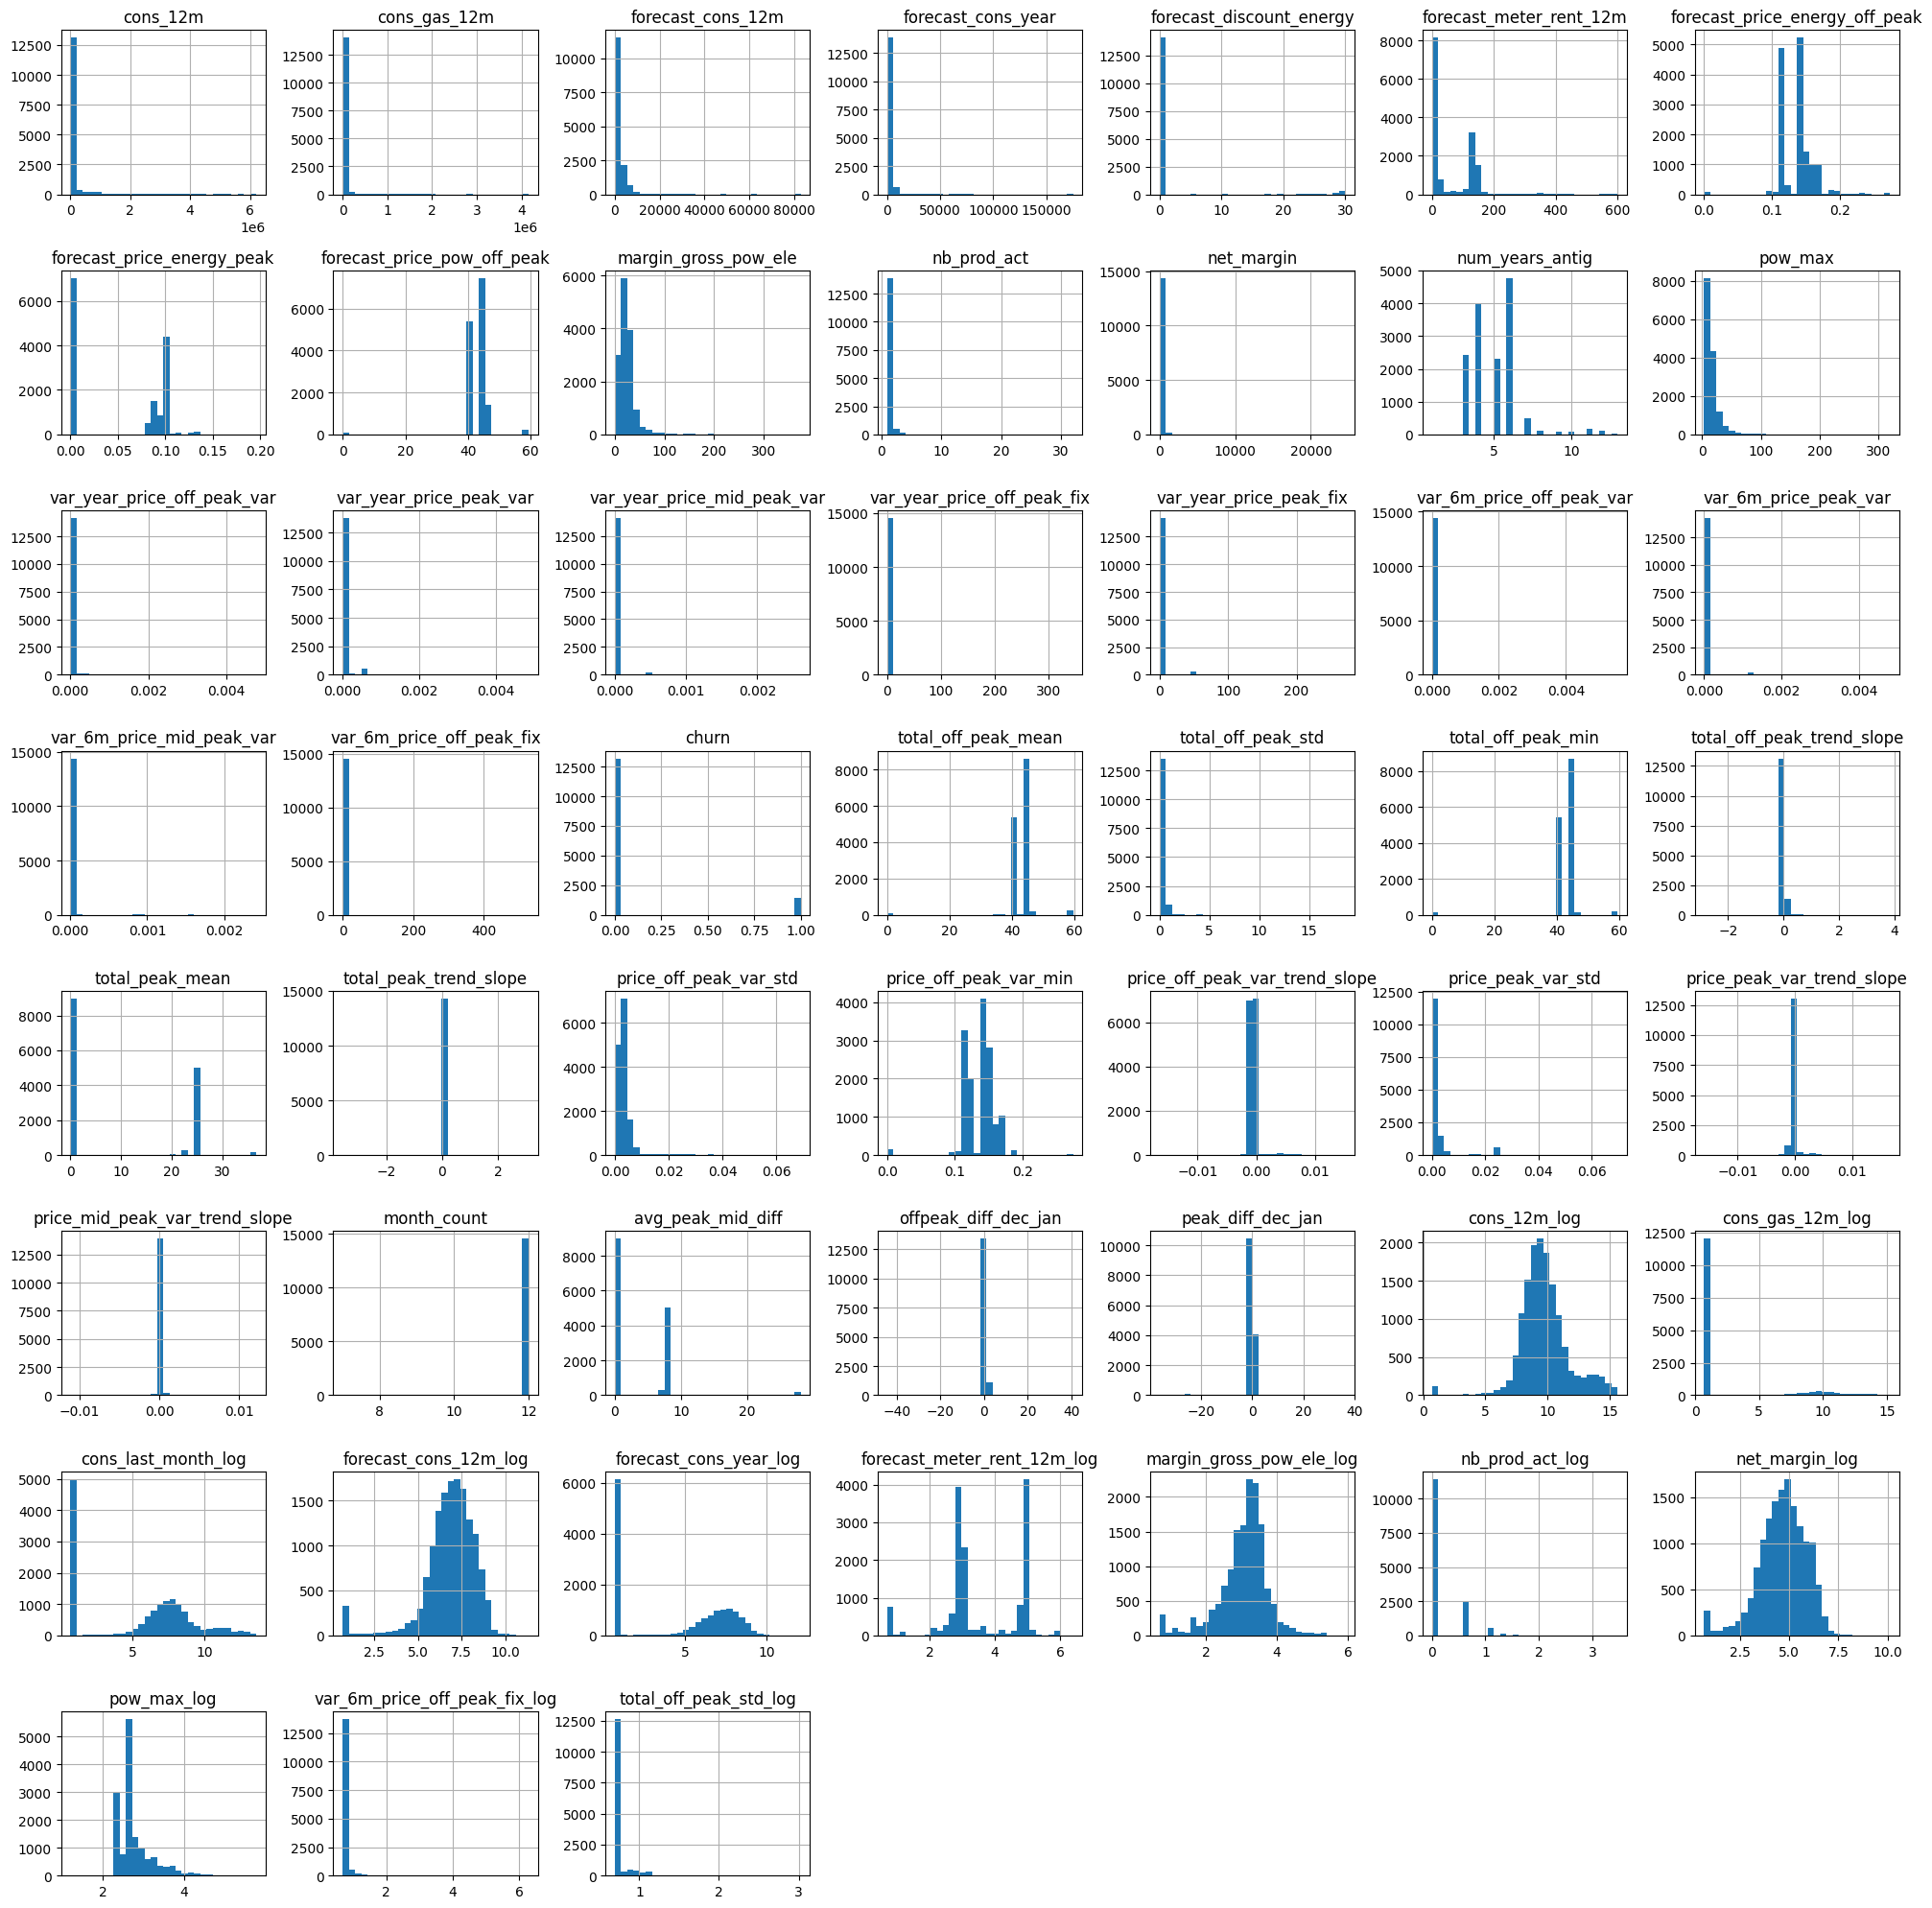

In [18]:

# Check skewness for all numeric columns
num_cols = final_df.select_dtypes(include=['float64', 'int64']).columns
skewness = final_df[num_cols].skew().sort_values()
print("\nSkewness per column:\n", skewness)

# Plot histograms for all numeric columns (adjust grid size as needed)
final_df[num_cols].hist(figsize=(20, 20), bins=30)
plt.tight_layout()
plt.show()